# 06 — Consensus and Comparative Folding

## Learning objectives

By the end of this notebook you will be able to:

- Explain why folding a **multiple sequence alignment** (MSA) can give more
  reliable structure predictions than folding any single sequence alone.
- Compute a consensus secondary structure with `RNA.alifold`, and consensus
  / most-informative sequences with `RNA.aln_consensus_sequence` and
  `RNA.aln_consensus_mis`.
- Read a **covariation score (pscore)**: what a large positive value means,
  what a strongly negative value means, and how it rewards *compensatory
  mutations*.
- Build a comparative `fold_compound` from an alignment and compute its
  partition function and base-pair probabilities, just as in notebook 3.

**Prerequisites**: [02_mfe_folding.ipynb](02_mfe_folding.ipynb) (MFE folding of
a single sequence) and [03_partition_probabilities.ipynb](03_partition_probabilities.ipynb)
(partition function, base-pair probabilities).


## 1. Introduction & motivation

Every notebook so far has folded **one sequence in isolation**. But evolution
gives us something extra: families of related sequences (homologs) that fold
into the *same* structure, even though their exact nucleotide sequences have
drifted apart. If a base pair is functionally important, mutations that break
it tend to be lethal — *unless* the partner base mutates too, in a way that
restores pairing. Such a **compensatory mutation** (e.g. a G–C pair becoming
A–U in another species, at the same two alignment columns) is strong evidence
that those two columns really do pair in the shared structure, independent of
what either sequence's nearest-neighbor energy alone would predict.

**Comparative folding** (the method behind the `RNAalifold` tool) exploits
this: instead of minimizing the free energy of one sequence, it folds a
**multiple sequence alignment**, scoring each candidate structure by combining
(1) the average folding free energy across all aligned sequences and (2) a
**covariation bonus** for column pairs that show compensatory mutations (and a
penalty for pairs that look structurally inconsistent across the alignment).

**Roadmap**: theory first (the alifold scoring function and what a "pscore"
measures), then a small hand-designed alignment where individual sequences
fold weakly or not at all, but the family as a whole strongly supports one
consensus structure — directly demonstrating why "more sequences, more
confidence" holds even when no single sequence is convincing on its own.


## 2. Theoretical background

### 2.1 From one sequence to an alignment

A multiple sequence alignment $A = (x^{(1)}, x^{(2)}, \ldots, x^{(K)})$ is a
set of $K$ homologous sequences, each padded with gap characters (`-`) so that
all sequences have the same length $L$ (the number of *alignment columns*).
Column $c$ of the alignment corresponds to (possibly) a different sequence
position in each $x^{(k)}$.

### 2.2 The alifold scoring function

For a candidate consensus structure $s$ (a set of column pairs $(c, c')$),
`RNAalifold` minimizes a combined score

$$
F(s \mid A) \;=\; \underbrace{\frac{1}{K}\sum_{k=1}^{K} \Delta G\big(s \mid x^{(k)}\big)}_{\text{average folding energy}}
\;-\; \underbrace{\sum_{(c,c') \in s} \psi(c, c')}_{\text{covariation bonus}}
$$

- The first term is the ordinary nearest-neighbor free energy (notebook 2),
  averaged over all sequences in the alignment that have nucleotides (not
  gaps) at columns $c$ and $c'$.
- The second term, $\psi(c,c')$ — the **pscore** — rewards column pairs where
  different sequences use *different but still complementary* base pairs
  (compensatory mutations: e.g. one sequence has G–C, another has A–U at the
  same columns) and penalizes column pairs where some sequences could not form
  a valid base pair at all.

A consensus structure with **many high-pscore pairs** is one where the
evolutionary record itself argues for those pairs — independent of whether any
single sequence's folding energy alone would have selected them.

### 2.3 Reading a pscore

`RNA.aln_pscore` returns, for every column pair $(c,c')$, a score in
**deciban-like units** (the same units RNAalifold reports, roughly
$10\times$kcal/mol-equivalent):

| pscore value | Interpretation |
| :--- | :--- |
| Large positive (e.g. $\geq 200$) | Strong compensatory-mutation support: the pair is consistent across the alignment, and at least two distinct base-pair types are observed (true covariation). |
| Small positive / zero | The pair is consistent (no sequence contradicts it) but with little or no type variation — i.e. it's conserved, not *co*varying. |
| Strongly negative (e.g. $-10000$) | At least one sequence cannot form *any* valid base pair between these two columns — the pair is structurally inconsistent with the alignment. |

### 2.4 Theory-to-API map

| Concept | ViennaRNA API |
| :--- | :--- |
| Consensus MFE structure + energy | `RNA.alifold(alignment)` $\to$ `(structure, mfe)` |
| Consensus sequence (most frequent base per column) | `RNA.aln_consensus_sequence(alignment)` |
| Most Informative Sequence (IUPAC codes for variable columns) | `RNA.aln_consensus_mis(alignment)` |
| Per-column conservation (Shannon entropy) | `RNA.aln_conservation_col(alignment)` |
| Mean pairwise sequence identity | `RNA.aln_mpi(alignment)` |
| Covariation / pscore matrix | `RNA.aln_pscore(alignment)` |
| Comparative fold compound (partition function, bpp, ...) | `RNA.fold_compound(alignment)` |

An "alignment" here is simply a Python list of equal-length strings (gaps
allowed as `-`).


In [1]:
# --- Setup -------------------------------------------------------------
import contextlib
import io

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import RNA

with contextlib.redirect_stderr(io.StringIO()):
    import forgi.graph.bulge_graph as fgb
    import forgi.visual.mplotlib as fvm

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
PALETTE = sns.color_palette("deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})


def draw_structure(ax, sequence, structure, title):
    bg = fgb.BulgeGraph.from_dotbracket(structure, sequence)
    fvm.plot_rna(bg, ax=ax, text_kwargs={"fontsize": 7}, lighten=0.3)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()


def pscore_matrix(alignment):
    '''Return the full pscore matrix (1-indexed, (L+1) x (L+1)) for an alignment.'''
    raw = RNA.aln_pscore(alignment)
    n = len(alignment[0])
    matrix = np.zeros((n + 1, n + 1))
    for i, row in enumerate(raw):
        for j, value in enumerate(row):
            matrix[i, j] = value
    return matrix


## 3. Worked example 1 — a toy hairpin family

Construct a small, hand-designed alignment of five 14-nt sequences that all
*could* fold into the same hairpin `(((((....)))))` (a 5-bp stem around a
4-nt loop) — but using **every possible Watson-Crick pairing** for the stem,
end to end: G–C, C–G, A–U, U–A, and a mixed G–C/A–U stem. This is an
idealized but instructive case of perfect compensatory variation.


In [2]:
sequences = {
    "seq1 (G-C stem)": "GGGGGAAAACCCCC",
    "seq2 (C-G stem)": "CCCCCAAAAGGGGG",
    "seq3 (A-U stem)": "AAAAAAAAAUUUUU",
    "seq4 (U-A stem)": "UUUUUAAAAAAAAA",
    "seq5 (mixed stem)": "GCGCGAAAACGCGC",
}
alignment = list(sequences.values())

# Fold each sequence on its own, ignoring the others.
single_rows = []
for name, seq in sequences.items():
    fc = RNA.fold_compound(seq)
    structure, mfe = fc.mfe()
    single_rows.append({"sequence": name, "seq": seq, "structure": structure, "mfe": mfe})
single_df = pd.DataFrame(single_rows)
single_df


,sequence,seq,structure,mfe
0,seq1 (G-C stem),GGGGGAAAACCCCC,(((((....))))),-8.7
1,seq2 (C-G stem),CCCCCAAAAGGGGG,(((((....))))),-9.1
2,seq3 (A-U stem),AAAAAAAAAUUUUU,..............,0.0
3,seq4 (U-A stem),UUUUUAAAAAAAAA,..............,0.0
4,seq5 (mixed stem),GCGCGAAAACGCGC,(((((....))))),-7.1


**Reading the table**: seq1, seq2, and seq5 fold confidently into the
intended hairpin on their own. But **seq3 and seq4 — pure poly-A/poly-U
stems — don't fold at all** (`mfe = 0.0`, the all-unpaired structure): five
consecutive A–U pairs plus a 4-nt loop simply isn't stable enough for the
nearest-neighbor model to prefer it over staying unpaired. If these were the
*only* sequences you had, you'd conclude they have no defined structure.


Now fold the **alignment** with `RNA.alifold` and compare.

In [3]:
consensus_structure, consensus_mfe = RNA.alifold(alignment)
consensus_seq = RNA.aln_consensus_sequence(alignment)
mis_seq = RNA.aln_consensus_mis(alignment)
mpi = RNA.aln_mpi(alignment)

print(f"Consensus structure: {consensus_structure}")
print(f"Consensus (alifold) score: {consensus_mfe:.2f}")
print(f"Consensus sequence:  {consensus_seq}")
print(f"Most informative seq: {mis_seq}")
print(f"Mean pairwise identity: {mpi}%")


Consensus structure: (((((....)))))
Consensus (alifold) score: -7.74
Consensus sequence:  GCGCGAAAACGCGC
Most informative seq: KYKYKAAAAYKYKY
Mean pairwise identity: 42%


**Reading the output**: `alifold` confidently assigns the full
`(((((....)))))` hairpin to the *entire alignment* — including seq3 and seq4,
which individually showed **no** structure at all. The mean pairwise identity
is low (~40%): these sequences barely look alike at the nucleotide level. What
they share is *covariation* — every stem column pair uses a different,
mutually-compatible base pair across the five sequences. The most informative
sequence (`mis_seq`) uses IUPAC ambiguity codes (`K` = G or U, `Y` = C or U) to
show exactly which columns vary while remaining complementary.


### 3.1 Visualizing the consensus structure and per-column conservation

Draw the consensus structure (using the consensus sequence for labeling), and
plot the per-column Shannon entropy to see which columns are conserved
(the loop) vs. variable-but-paired (the stem).


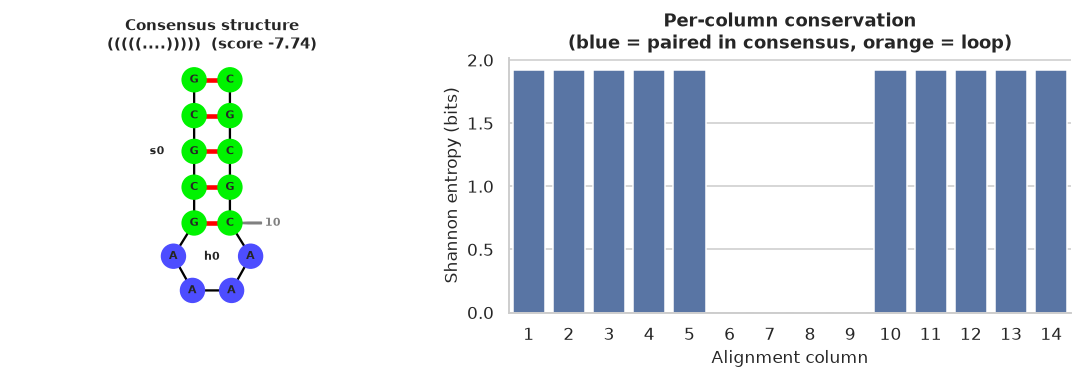

In [4]:
# aln_conservation_col returns a 1-indexed vector (index 0 is unused).
conservation = np.array(RNA.aln_conservation_col(alignment))[1:]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})

draw_structure(axes[0], consensus_seq, consensus_structure,
               f"Consensus structure\n{consensus_structure}  (score {consensus_mfe:.2f})")

positions = np.arange(1, len(consensus_seq) + 1)
colors = [PALETTE[0] if consensus_structure[p - 1] != "." else PALETTE[1] for p in positions]
sns.barplot(x=positions, y=conservation, hue=positions, palette=colors, legend=False, ax=axes[1])
axes[1].set_xlabel("Alignment column")
axes[1].set_ylabel("Shannon entropy (bits)")
axes[1].set_title("Per-column conservation\n(blue = paired in consensus, orange = loop)")
sns.despine(ax=axes[1])

fig.tight_layout()
plt.show()


**Reading the figure**: the loop columns (6-9, orange) have entropy
$\approx 0$ — every sequence has `A` there, fully conserved. The stem columns
(blue) have **high entropy** (~1.9 bits, close to the maximum for 4 symbols) —
every sequence uses a *different* nucleotide there. High entropy alone would
normally suggest "unimportant, not conserved". But combined with the
consensus structure, it tells the real story: these columns are
**covarying**, not unconstrained — the *pairing*, not the *identity*, is
conserved.


## 4. Worked example 2 — reading the covariation (pscore) matrix

The entropy plot above can't distinguish "covarying" from "just variable" —
for that we need the **pscore** matrix, which explicitly checks whether
variable columns remain *pairable* across the alignment.


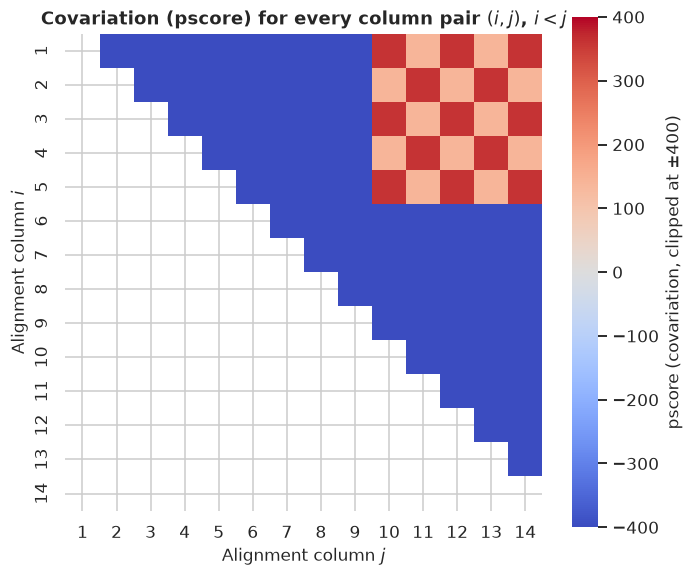

pscore for each consensus base pair:
  ( 1, 14): pscore = 360
  ( 2, 13): pscore = 360
  ( 3, 12): pscore = 360
  ( 4, 11): pscore = 360
  ( 5, 10): pscore = 360


In [5]:
pscores = pscore_matrix(alignment)
n = len(consensus_seq)

# Restrict to the upper triangle (i < j) for display.
display_matrix = np.full((n, n), np.nan)
for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        display_matrix[i - 1, j - 1] = pscores[i, j]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
# Clip the color scale: pscore=-10000 is a hard "impossible pair" veto, not a
# graded penalty, so let it saturate the low end rather than swamping the
# scale and hiding the (much smaller in magnitude) positive covariation scores.
sns.heatmap(display_matrix, ax=ax, cmap="coolwarm", center=0, vmin=-400, vmax=400,
            cbar_kws={"label": "pscore (covariation, clipped at ±400)"}, square=True,
            xticklabels=range(1, n + 1), yticklabels=range(1, n + 1))
ax.set_xlabel("Alignment column $j$")
ax.set_ylabel("Alignment column $i$")
ax.set_title("Covariation (pscore) for every column pair $(i,j)$, $i<j$")
fig.tight_layout()
plt.show()

print("pscore for each consensus base pair:")
for i in range(1, n + 1):
    j = None
    # crude dot-bracket pair lookup
    stack = []
    for pos, ch in enumerate(consensus_structure, start=1):
        if ch == "(":
            stack.append(pos)
        elif ch == ")":
            partner = stack.pop()
            if partner == i:
                j = pos
    if j is not None:
        print(f"  ({i:2d}, {j:2d}): pscore = {pscores[i, j]:.0f}")


**Reading the heatmap**: a $5\times5$ block of column pairs — every
pairing between columns $1$-$5$ and columns $10$-$14$ — lights up strongly
**positive** (red): both halves of the stem vary in lockstep across the
alignment, so almost any pairing between them is at least *compatible* with
some base-pair type in every sequence. The five **consensus** pairs
$(1,14), (2,13), \ldots, (5,10)$ reach the maximum score ($360$, since *every*
sequence uses a different but valid type there); the off-diagonal pairs within
the block score lower ($140$) but are still positive. `alifold` doesn't pick
the consensus structure from covariation alone — it also requires the pairs to
be **non-crossing and non-overlapping** (a valid secondary structure), which
the nested diagonal $(1,14),(2,13),\ldots$ satisfies and the off-diagonal pairs
do not (they'd cross each other). Everywhere else — pairs involving the
fully-conserved loop columns $6$-$9$ — is strongly **negative** (blue, pscore
$=-10000$, clipped at $-400$): at least one sequence in the alignment cannot
form a valid pair there (e.g. two loop columns are both `A` in every sequence
— pairing A with A is never allowed). The combination of "high covariation" +
"forms a valid nested structure" is exactly the signal `alifold` uses to pick
out the hairpin.


## 5. Worked example 3 — robustness to a "noisy" family member

Real sequence families always include some noise: sequencing errors,
lineage-specific deviations, or genuinely degenerate copies. Add a sixth
sequence, `seq6`, that has a **single point mutation** disrupting one stem
pair (position 5 changed from `G` to `A`, so it can no longer pair with `C` at
position 10). Folded alone, this sequence loses one base pair from its stem.
Does adding it to the alignment change the family's consensus structure?


In [6]:
seq6 = "GGGGAAAAACCCCC"  # position 5: G -> A

fc6 = RNA.fold_compound(seq6)
structure6_alone, mfe6_alone = fc6.mfe()
print(f"seq6 folded alone:       {structure6_alone}  ({mfe6_alone:.2f} kcal/mol)")
print(f"seq1 for comparison:     {single_df.loc[0, 'structure']}  (consensus pair count: 5)")

alignment6 = alignment + [seq6]
structure6, mfe6 = RNA.alifold(alignment6)
pscores6 = pscore_matrix(alignment6)

print(f"\nConsensus structure (6 sequences): {structure6}  (score {mfe6:.2f})")
print(f"pscore(5,10) before adding seq6: {pscores[5, 10]:.0f}")
print(f"pscore(5,10) after adding seq6:  {pscores6[5, 10]:.0f}")


seq6 folded alone:       ((((.....)))).  (-6.10 kcal/mol)
seq1 for comparison:     (((((....)))))  (consensus pair count: 5)

Consensus structure (6 sequences): (((((....)))))  (score -7.49)
pscore(5,10) before adding seq6: 360
pscore(5,10) after adding seq6:  200


**Reading the output**: folded alone, `seq6` loses the $(5,10)$ pair —
its MFE structure has only 4 stem base pairs. But the **6-sequence consensus
structure is unchanged**: still the full 5-bp hairpin. Adding `seq6` *did*
reduce the pscore for $(5,10)$ — from $360$ to $200$ — because now one
sequence in the family contradicts that pair. But $200$ is still strongly
positive: the other five sequences' covariation evidence outweighs one
outlier. **This is the practical payoff of comparative folding**: a single
noisy or partially-degenerate sequence doesn't derail the consensus, as long
as the rest of the family agrees.


## 6. Case study — partition function for an alignment

Just like a single-sequence `fold_compound` (notebook 3), a comparative
`fold_compound` built from an alignment supports `pf()` and `bpp()` — giving
**ensemble** base-pair probabilities for the consensus structure, pooled
across the whole family.


In [7]:
fc_aln = RNA.fold_compound(alignment6)
mfe_structure, mfe_energy = fc_aln.mfe()
fc_aln.exp_params_rescale(mfe_energy)
pf_structure, pf_energy = fc_aln.pf()

bpp = np.array(fc_aln.bpp())
n = len(consensus_seq)

print(f"Comparative MFE structure: {mfe_structure}  ({mfe_energy:.2f})")
print(f"Comparative ensemble free energy: {pf_energy:.2f}")
print("\nBase-pair probabilities for the consensus stem:")
for i in range(1, n + 1):
    j = n + 1 - i
    if mfe_structure[i - 1] == "(":
        print(f"  p({i:2d},{j:2d}) = {bpp[i, j]:.3f}")


Comparative MFE structure: (((((....)))))  (-7.49)
Comparative ensemble free energy: -7.54

Base-pair probabilities for the consensus stem:
  p( 1,14) = 0.968
  p( 2,13) = 0.998
  p( 3,12) = 0.998
  p( 4,11) = 0.998
  p( 5,10) = 0.952


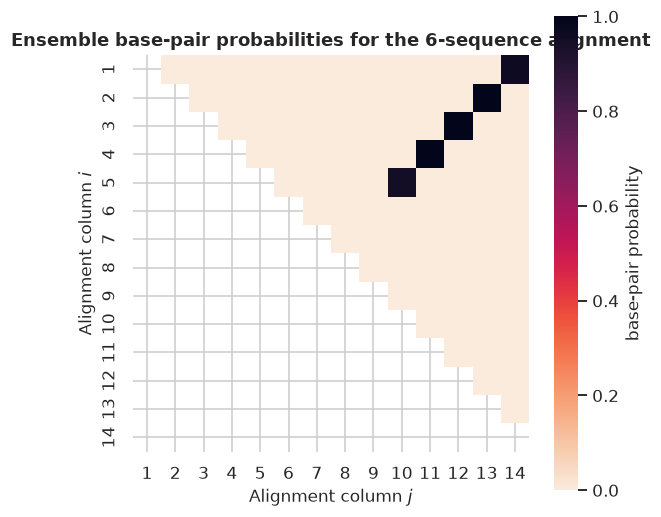

In [8]:
fig, ax = plt.subplots(figsize=(5.5, 5))
display_bpp = np.full((n, n), np.nan)
for i in range(1, n + 1):
    for j in range(i + 1, n + 1):
        display_bpp[i - 1, j - 1] = bpp[i, j]

sns.heatmap(display_bpp, ax=ax, cmap="rocket_r", vmin=0, vmax=1,
            cbar_kws={"label": "base-pair probability"}, square=True,
            xticklabels=range(1, n + 1), yticklabels=range(1, n + 1))
ax.set_xlabel("Alignment column $j$")
ax.set_ylabel("Alignment column $i$")
ax.set_title("Ensemble base-pair probabilities for the 6-sequence alignment")
fig.tight_layout()
plt.show()


**Reading the figure**: every consensus stem pair has $p \approx 1$ —
the comparative ensemble is essentially certain about the hairpin, despite
two of the six individual sequences (seq3, seq4) showing *zero* structure
alone and a sixth (seq6) missing one pair. This is the central message of
comparative folding: **pooling weak, partial, or noisy single-sequence
signals across a family can produce a confident consensus that no individual
sequence's energy landscape would justify on its own.**


## 7. Best practices and common pitfalls

- **Alignment quality dominates everything.** `alifold` trusts the alignment's
  column correspondences completely — a misaligned column will be scored as
  if real sequences occupy it, producing spurious or missing covariation
  signal. Garbage in, garbage out.
- **Mean pairwise identity (MPI) is a sanity check, not a requirement.** Very
  *high* MPI (>90%) means the sequences are nearly identical — there may not
  be enough variation to generate covariation signal at all. Very *low* MPI
  (<30%) may mean the alignment itself is unreliable. Useful comparative
  signal often comes from intermediate identity with a handful of
  well-aligned, functionally constrained columns.
- **A single sequence's `mfe() == 0.0` (no structure) doesn't mean "no
  structure exists"** — as seq3/seq4 showed, it may simply mean that sequence
  alone is too weak; always check the family-level consensus before concluding
  a region is unstructured.
- **pscore $= -10000$ is a hard veto, not "very unlikely".** It means at least
  one alignment column pair literally cannot form any valid base pair (e.g.
  both columns are `A` in some sequence) — `alifold` will essentially never
  place a consensus pair there.
- **`RNA.fold_compound(alignment)` works like a single-sequence fold compound**
  for everything downstream — `mfe()`, `pf()`, `bpp()` all "just work" on an
  alignment, returning consensus-level quantities.


## 8. Summary

- Comparative folding scores a **consensus structure** against an entire
  alignment, combining average per-sequence folding energy with a
  **covariation (pscore) bonus** for compensatory mutations.
- `RNA.alifold(alignment)` returns the consensus structure and its score;
  `RNA.aln_consensus_sequence` / `RNA.aln_consensus_mis` summarize the
  alignment as a single sequence; `RNA.aln_pscore` exposes the covariation
  evidence per column pair.
- A family can confidently support a structure that **no single member's MFE
  alone would predict** — including members that fold to nothing on their
  own — as long as the family collectively covaries.
- `RNA.fold_compound(alignment)` extends `pf()`/`bpp()` (notebook 3) to the
  comparative setting, giving ensemble-level confidence for the consensus.

**Next**: [07_interactions.ipynb](07_interactions.ipynb) shifts from "one
molecule, many homologs" to "two different molecules, one interaction" —
RNA-RNA duplex formation and intermolecular structures.


## 9. Exercises

1. Build a new 5-sequence alignment for a **3-bp stem / 4-nt loop** hairpin
   (`(((....)))`, 11 nt) using the same "every pair type" idea from Section 3.
   Do seq3/seq4-style poly-A/poly-U sequences still fold to nothing on their
   own? Does `alifold` still recover the full stem?
2. In Section 5, change `seq6`'s mutation so that position 5 becomes `C`
   instead of `A` (i.e. `GGGGCAAAACCCCC` — note position 5 would then pair
   with position 10's `C` as C–C, still invalid). Recompute `pscore(5,10)`.
   Is the penalty larger or smaller than for the `G`$\to$`A` mutation? Why
   might that be (hint: consider what `pscore` does with a column pair where
   *no* sequence can form a valid pair at all vs. one where most can)?
3. Using `RNA.aln_conservation_col`, find the alignment column with the
   *lowest* entropy that is **not** part of the consensus structure. Is there
   such a column in our 6-sequence alignment? What would it mean if there
   were (a conserved-but-unpaired position, e.g. a catalytic loop residue)?
